# Text Classification with Neural Networks

NYU faculty, administrators, staff, and students may apply for a WRDS account. Non-PhD students can request a temporary Research Assistant account when working with faculty.

- Visit [Wharton Research Database Services](https://wrds-www.wharton.upenn.edu/)
- Click the Register button.
- Complete the form, read the Terms of Use, and submit.
- The NYU Representative for WRDS will review your application and affiliation.
- Upon approval, WRDS will email instructions for setting your password.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2025-12-04 07:57:33.626814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Handwritten Digits Problem

Below, build a model with the following:

- A Linear layer with 100 neurons
- A ReLU activation on this layer
- A Linear layer with another 100 neurons
- A ReLU activation on this layer
- A Linear output layer with 10 neurons

Use the `optim.SGD` to optimize the parameters of the model.

Use `nn.CrossEntropyLoss` as your loss function for multiclass classification.

In [10]:
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Normalize, ToTensor

In [11]:
train = MNIST(root = '.', download = True)

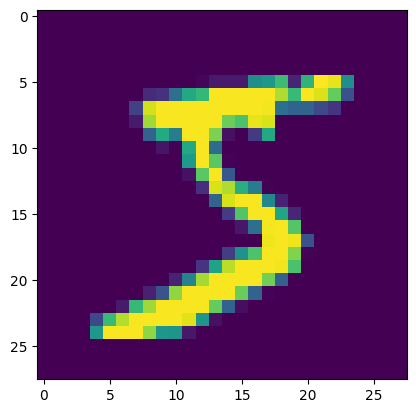

In [13]:
plt.imshow(train[0][0])

In [14]:
type(train[0][0])

PIL.Image.Image

In [15]:
train = MNIST(root = '.', download = True, transform=ToTensor())

In [16]:
type(train[0][0])

torch.Tensor

In [18]:
transforms = Compose([ToTensor(), Normalize((0.5,), (0.5))])

In [19]:
train = MNIST(root = '.', download = True, transform=transforms)

In [20]:
trainloader = DataLoader(train, batch_size=32)

In [36]:
model = nn.Sequential(nn.Flatten(),
                      nn.Linear(28*28, 100),
                      nn.ReLU(),
                      nn.Linear(100, 100),
                      nn.ReLU(),
                      nn.Linear(100, 10))
                      

In [37]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [38]:
from tqdm import tqdm

In [39]:
def train_function(model, loader, epochs, optimizer, loss_fn, losses = []):
    '''
    The function trains a pytorch model given a model,
    number of training epochs, optimizer, and loss function.
    It returns a list of losses from training.
    '''
    for epoch in tqdm(range(epochs)):
        for X,Y in loader:
            yhat = model(X)
            loss = loss_fn(yhat, Y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return losses

In [40]:
losses = train_function(model, trainloader, 20, optimizer, loss_fn)

100%|███████████████████████████████████████████| 20/20 [03:36<00:00, 10.81s/it]


#### Classifying Spam

In [ ]:
#read in data
spam = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/sms_spam.csv')

In [ ]:
#take a peek
spam.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#create a tokenizer
tokenizer = Tokenizer(num_words = 500)

In [ ]:
#fit the tokenizer -- learns the vocabulary
tokenizer.fit_on_texts(spam['text'].values)

In [ ]:
#look at tokenizer
tokenizer.num_words

500

In [ ]:
#create document term matrix (binarized)
dtm = tokenizer.texts_to_matrix(spam['text'].values)

In [ ]:
#take a peek
dtm

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [ ]:
tokenizer.index_word[2]

'to'

In [ ]:
spam['text'][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [ ]:
[tokenizer.index_word[i] for i in range(1, 500)]

['i',
 'to',
 'you',
 'a',
 'the',
 'u',
 'and',
 'in',
 'is',
 'me',
 'my',
 'for',
 'your',
 'it',
 'of',
 'call',
 'have',
 'on',
 '2',
 'that',
 'now',
 'are',
 'so',
 'but',
 'not',
 'or',
 'do',
 'can',
 'at',
 "i'm",
 'ur',
 'get',
 'will',
 'if',
 'be',
 'with',
 'just',
 'no',
 'we',
 'this',
 '4',
 'gt',
 'lt',
 'up',
 'when',
 'ok',
 'free',
 'from',
 'go',
 'how',
 'all',
 'out',
 'what',
 'know',
 'like',
 'good',
 'then',
 'got',
 'come',
 'was',
 'its',
 'am',
 'time',
 'only',
 'day',
 'love',
 'there',
 'send',
 'he',
 'want',
 'text',
 'as',
 'txt',
 'one',
 'going',
 'by',
 'ü',
 "i'll",
 'need',
 'home',
 'about',
 'r',
 'lor',
 'sorry',
 'stop',
 'still',
 'see',
 'n',
 'back',
 'today',
 'da',
 'our',
 'dont',
 'reply',
 'k',
 "don't",
 'she',
 'mobile',
 'take',
 'hi',
 'tell',
 'new',
 'please',
 'later',
 'her',
 'pls',
 'any',
 'think',
 'been',
 'they',
 'phone',
 'here',
 'week',
 'did',
 'dear',
 'some',
 'well',
 'has',
 '1',
 'night',
 'much',
 'd',
 'gre

In [ ]:
class TextDataset(Dataset):
  def __init__(self, X, y):
    super().__init__()
    self.x = torch.tensor(X, dtype = torch.float)
    self.y = torch.tensor(y, dtype = torch.float)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

In [ ]:
X = dtm
y = np.where(spam['type'] == 'ham', 0, 1)

In [ ]:
Xt = torch.tensor(X, dtype = torch.float32)
yt = torch.tensor(y, dtype = torch.float32)

In [ ]:
from torch.utils.data import TensorDataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Xt, yt, test_size=.2)

In [ ]:
X_train

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
#create data class
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [ ]:
#dataset and loader -- making batches of our bigger dataset
trainloader = DataLoader(train_dataset, batch_size = 32)
#dataset and loader
testloader = DataLoader(test_dataset, batch_size = 32)

In [ ]:
model = nn.Sequential(nn.Linear(in_features=500, out_features=1000),
                      nn.ReLU(),
                      nn.Linear(1000, 100),
                      nn.ReLU(),
                      nn.Linear(100, 1),
                      nn.Sigmoid()
                      )

In [ ]:
model(Xt)

tensor([[0.4742],
        [0.4725],
        [0.4767],
        ...,
        [0.4751],
        [0.4696],
        [0.4744]], grad_fn=<SigmoidBackward0>)

In [ ]:
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [ ]:
from tqdm import tqdm

In [ ]:
#keep track of the losses
losses = []
#train it for 20 epochs
for epoch in tqdm(range(20)):
  #iterate over the batches
  for x,y in trainloader:
    #feeds data into model
    yhat = model(x)
    #evaluate the predictions
    loss = loss_fn(yhat, y.unsqueeze(1))
    #update the weights/params
    optimizer.zero_grad() #pytorch house cleaning
    loss.backward() #pass info backwards
    optimizer.step() #step towards less loss
    losses.append(loss.item()) #tracking the loss


100%|██████████| 20/20 [00:39<00:00,  1.98s/it]


In [ ]:
model(X_train)

tensor([[5.1285e-06],
        [2.1966e-11],
        [1.0000e+00],
        ...,
        [1.5508e-16],
        [3.2522e-16],
        [1.2212e-10]], grad_fn=<SigmoidBackward0>)

In [ ]:
train_predictions = model(X_train)
ytrain_preds = torch.where(train_predictions > .5, 1, 0)

In [ ]:
ytrain_preds.shape

torch.Size([4459, 1])

In [ ]:
y_train.shape

torch.Size([4459])

In [ ]:
torch.sum(ytrain_preds.squeeze(1) == y_train)/len(y_train)

tensor(0.9996)

In [ ]:
ytest_preds = torch.where(model(X_test) > .5, 1, 0)
torch.sum(ytest_preds.squeeze(1) == y_test)/len(y_test)

tensor(0.9874)

In [ ]:
#loss and optimizer
class TextModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.lin1 = nn.Linear(in_features = 500, out_features = 100)
    self.lin2 = nn.Linear(100, 100)
    self.lin3 = nn.Linear(100, 1)
    self.sigmoid = nn.Sigmoid()
    self.act = nn.ReLU()

  def forward(self, x):
    x = self.act(self.lin1(x))
    x = self.act(self.lin2(x))
    return self.sigmoid(self.lin3(x))




In [ ]:
#training function
model = TextModel()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
loss_fn = nn.BCELoss()

In [ ]:
#torch.save(model, 'textmodel.pt')

In [ ]:
from tqdm import tqdm

In [ ]:
#evaluate
for epoch in tqdm(range(100)):
  losses = 0
  for x,y in trainloader:
    yhat = model(x)
    y = y.reshape(-1, 1)
    loss = loss_fn(yhat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses += loss.item()
  if epoch % 10 == 0:
    print(f'Epoch {epoch} Loss: {losses}')

  2%|▏         | 2/100 [00:00<00:22,  4.44it/s]

Epoch 0 Loss: 17.001398101157974


 12%|█▏        | 12/100 [00:02<00:18,  4.83it/s]

Epoch 10 Loss: 0.30588380191235665


 22%|██▏       | 22/100 [00:04<00:14,  5.29it/s]

...

 82%|████████▏ | 82/100 [00:16<00:03,  5.69it/s]

Epoch 80 Loss: 6.425228226558245


 91%|█████████ | 91/100 [00:18<00:01,  4.88it/s]

Epoch 90 Loss: 6.420938703532891


100%|██████████| 100/100 [00:20<00:00,  4.99it/s]


In [ ]:
Xt = torch.tensor(X_test, dtype = torch.float)

In [ ]:

output = model(Xt) #model predictions

In [ ]:
output

tensor([[1.0000e+00],
        [4.3710e-09],
        [0.0000e+00],
        ...,
        [9.7863e-23],
        [7.6954e-32],
        [1.6741e-13]], grad_fn=<SigmoidBackward0>)

In [ ]:
#Converting probabilities to prediction
preds = np.where(np.array(output.detach()) >= .5, 1, 0)

In [ ]:
preds.shape

(1115, 1)

In [ ]:
y = np.where(spam['type'] == 'ham', 0, 1)

In [ ]:
sum(preds[:, 0] == y_test)/len(y_test)

np.float64(0.9865470852017937)

In [ ]:
1 - sum(y_test)/len(y_test)

np.float64(0.8780269058295964)

### Basic RNN

![](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Recurrent_neural_network_unfold.svg/440px-Recurrent_neural_network_unfold.svg.png)

In [ ]:
#create sequences
sequences = tokenizer.texts_to_sequences(spam['text'].values)

In [ ]:
#look at first sequence
sequences[0]

[49, 471, 64, 8, 88, 123, 351, 148, 67, 58, 145]

In [ ]:
X_train[0]

tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 

In [ ]:
#compare to text
spam['text'].values[1]

'Ok lar... Joking wif u oni...'

In [ ]:
#pad and make all same length
sequences = pad_sequences(sequences, maxlen=100)

In [ ]:
#examine results
sequences[1].shape

(100,)

In [ ]:
sequences[1]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  46, 336, 472,   6], dtype=int32)

In [ ]:
#example rnn
rnn = nn.RNN(input_size = 100,
             hidden_size = 30,
             num_layers = 1,
             batch_first = True)

In [ ]:
#pass data through
sample_sequence = torch.tensor(sequences[1],
                               dtype = torch.float,
                               ).reshape(1, -1)
sample_sequence.shape

torch.Size([1, 100])

In [ ]:
#output
output, hidden = rnn(sample_sequence)

In [ ]:
#hidden
hidden.shape

torch.Size([1, 30])

In [ ]:
#linear layer
output.shape

torch.Size([1, 30])

In [ ]:
#pass through linear
lin1 = nn.Linear(in_features = 30, out_features = 1)

In [ ]:
lin1(output)

tensor([[-0.2344]], grad_fn=<AddmmBackward0>)

In [ ]:
for x, y in trainloader:
  print(x.shape)
  break

torch.Size([32, 500])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(sequences, yt)

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), y_train)
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), y_test)

In [ ]:
trainloader = DataLoader(train_dataset, batch_size = 32)
testloader = DataLoader(test_dataset, batch_size = 32)

In [ ]:
model = nn.Sequential(nn.RNN(input_size = 100, hidden_size = 50, num_layers=2),
                      nn.Linear(in_features = 50, out_features=1),
                      nn.Sigmoid())


In [ ]:
ex_rnn = nn.RNN(input_size = 100, hidden_size = 50, num_layers=2)
ex_rnn(train_dataset[0][0].unsqueeze(0))

(tensor([[ 0.1487,  0.2431,  0.6609, -0.5296,  0.4776,  0.9139,  0.3435, -0.6055,
          -0.0508, -0.3429, -0.4797,  0.7480, -0.2520, -0.0965,  0.1264,  0.5294,
          -0.0484,  0.6959, -0.2636, -0.6176, -0.4428,  0.0039, -0.6348,  0.8819,
          -0.0500, -0.2588,  0.0651,  0.4257,  0.3555, -0.3482, -0.1706,  0.5239,
          -0.6145,  0.1178, -0.3609, -0.4668, -0.5362, -0.4299, -0.0999, -0.6766,
           0.7781,  0.0086, -0.4132, -0.3846,  0.2893, -0.5338, -0.6386,  0.5970,
           0.1103,  0.2914]], grad_fn=<SqueezeBackward1>),
 tensor([[ 1.0000, -1.0000, -1.0000,  1.0000,  1.0000,  1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -0.9990,  1.0000, -1.0000,  1.0000,  1.0000,  1.0000,
          -1.0000, -1.0000,  1.0000, -1.0000, -1.0000, -1.0000,  1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000,  0.8632,  1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000,  1.0000, -1.0000, -1.0000, -1.0000,
           1.0000, -1.0000,  1.0000, -1

In [ ]:
class TextDataset(Dataset):
  def __init__(self, X, y):
    super().__init__()
    self.x = torch.tensor(X, dtype = torch.float)
    self.y = torch.tensor(y, dtype = torch.float)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

In [ ]:
#class
class BasicRNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.rnn = nn.RNN( input_size = 100,
                    hidden_size = 50,
                    num_layers = 3,
                    batch_first = True  )
    self.lin1 = nn.Linear(in_features = 50, out_features=1000)
    self.lin2 = nn.Linear(1000, 100)
    self.lin3 = nn.Linear(100, 1)
    self.act = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x, _ = self.rnn(x) #extracting important information
    x = self.act(self.lin1(x)) #multilayer perceptron -- to predict
    x = self.act(self.lin2(x))
    x = self.sigmoid(self.lin3(x))
    return x


In [ ]:
#data
X = sequences
y = np.where(spam['type'] == 'spam', 1, 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)
traindata = TextDataset(X_train, y_train)
trainloader = DataLoader(traindata, batch_size = 32)

In [ ]:
#optimizer and loss
model = BasicRNN()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
loss_fn = nn.BCELoss()

In [ ]:
#train
for epoch in tqdm(range(100)):
  losses = 0
  for x,y in trainloader:
    yhat = model(x)
    y = y.reshape(-1, 1)
    loss = loss_fn(yhat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses += loss.item()
  if epoch % 10 == 0:
    print(f'Epoch {epoch} Loss: {losses}')

  1%|          | 1/100 [00:02<04:38,  2.81s/it]

Epoch 0 Loss: 54.801734544336796


 11%|█         | 11/100 [00:26<03:36,  2.43s/it]

Epoch 10 Loss: 48.3408587872982


 21%|██        | 21/100 [00:50<03:08,  2.38s/it]

...

 81%|████████  | 81/100 [03:24<00:50,  2.66s/it]

Epoch 80 Loss: 48.213553093373775


 91%|█████████ | 91/100 [03:50<00:24,  2.76s/it]

Epoch 90 Loss: 48.982448637485504


100%|██████████| 100/100 [04:13<00:00,  2.54s/it]


In [ ]:
Xt = torch.tensor(X_test, dtype = torch.float)

In [ ]:
output = model(Xt)

In [ ]:
preds = np.where(np.array(output.detach()) >= .5, 1, 0)

In [ ]:
#preds = output.argmax(axis = 1)

In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# y = np.where(spam['type'] == 'ham', 0, 1)

In [ ]:
# y.shape

In [ ]:
sum(preds.reshape(1115,) == y_test)/len(y_test)

np.float64(0.8753363228699551)

#### LSTM

In [ ]:
# nn.LSTM()
class BasicLSTM(nn.Module):
  def __init__(self):
    super().__init__()
    self.rnn = nn.LSTM(input_size = 100,
                    hidden_size = 100,
                    num_layers = 1,
                    batch_first = True)

    self.lin1 = nn.Linear(in_features = 100, out_features=100)
    self.lin2 = nn.Linear(in_features = 100, out_features = 1)
    self.act = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x, _ = self.rnn(x)
    x = self.act(self.lin1(x))
    x = self.lin2(x)
    return self.sigmoid(x)

In [ ]:
model = BasicLSTM()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
loss_fn = nn.BCELoss()

In [ ]:
#train
for epoch in range(10):
  losses = 0
  for x,y in trainloader:
    yhat = model(x)
    y = y.reshape(-1, 1)
    loss = loss_fn(yhat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses += loss.item()
  if epoch % 10 == 0:
    print(f'Epoch {epoch} Loss: {losses}')

In [ ]:
Xt = torch.tensor(X_test, dtype = torch.float)
output = model(Xt)
preds = np.where(np.array(output.detach()) >= .5, 1, 0)
sum(preds[:, 0] == y_test)/len(y_test)

In [ ]:
#pad and make all same length
sequences = pad_sequences(sequences, maxlen=30)

In [ ]:
sequences[0]

In [ ]:
X = sequences
y = np.where(spam['type'] == 'spam', 1, 0)
data = TextDataset(X, y)
loader = DataLoader(data, batch_size = 32)

In [ ]:
class RNN2(nn.Module):
  def __init__(self):
    super().__init__()
    self.rnn = nn.GRU(input_size = 30,
                    hidden_size = 30,
                    num_layers = 2,
                    batch_first = True)

    self.lin1 = nn.Linear(in_features = 30, out_features=100)
    self.lin2 = nn.Linear(in_features = 100, out_features = 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x, _ = self.rnn(x)
    x = self.lin1(x)
    x = self.lin2(x)
    return self.sigmoid(x)

In [ ]:
model = RNN2()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
loss_fn = nn.BCELoss()

In [ ]:
#train
for epoch in range(100):
  losses = 0
  for x,y in loader:
    yhat = model(x)
    y = y.reshape(-1, 1)
    loss = loss_fn(yhat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses += loss.item()
  if epoch % 10 == 0:
    print(f'Epoch {epoch} Loss: {losses}')

In [ ]:
Xt = torch.tensor(sequences, dtype = torch.float)
output = model(Xt)
preds = np.where(np.array(output.detach()) >= .5, 1, 0)
y = np.where(spam['type'] == 'ham', 0, 1)
sum(preds[:, 0] == y)/len(y)